# Trabajo Práctico  
## Compensación de planta mediante diseño en el dominio $s$

**Tema:** diseño de compensador para cumplir especificaciones dinámicas y error estacionario.

**Planta dada:**

$$
G_p(s)=\frac{s+40}{s^3+60s^2+875s}
$$

Equivalentemente:

$$
G_p(s)=\frac{s+40}{s(s+25)(s+35)}
$$

**Requerimientos de diseño:**

- Coeficiente de amortiguamiento relativo:

$$
\zeta = 0.628
$$

- Frecuencia natural:

$$
\omega_n = 21.324 \; rad/s
$$

- Constante de error de estado estacionario de velocidad:

$$
K_v = 3 \; rad/s
$$

**Objetivo:** diseñar un compensador estándar, verificar el cumplimiento de los requerimientos y comparar la respuesta al escalón antes y después de la compensación.

## Índice

1. Herramientas utilizadas  
2. Planteo de la planta  
3. Análisis inicial  
4. Interpretación de requerimientos  
5. Polo dominante deseado  
6. Constante de error de velocidad  
7. Modelo estándar del compensador  
8. Cálculo del compensador  
9. Sistema antes de compensar  
10. Sistema compensado  
11. Verificación de polos  
12. Verificación de $K_v$  
13. Respuesta al escalón antes y después  
14. Análisis frecuencial: Bode  
15. Análisis de Nyquist  
16. Lugar geométrico de las raíces  
17. Discusión técnica  
18. Conclusiones  
19. Código final resumido

# 1. Herramientas utilizadas

Para la resolución se utiliza Python en Google Colab con las siguientes librerías:

- `numpy`: cálculo numérico y manejo de polinomios.
- `scipy.signal`: representación de sistemas LTI, respuesta temporal y conversión de modelos.
- `matplotlib`: generación de gráficas.
- `scipy.optimize`: resolución numérica de ecuaciones no lineales.

La resolución se realiza en forma reproducible: todas las constantes y simulaciones se calculan dentro del notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.optimize import root
import math
import warnings

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True

# 2. Planteo de la planta

La planta dada es:

$$
G_p(s)=\frac{s+40}{s^3+60s^2+875s}
$$

Factorizando el denominador:

$$
s^3+60s^2+875s=s(s^2+60s+875)
$$

Como:

$$
s^2+60s+875=(s+25)(s+35)
$$

entonces:

$$
G_p(s)=\frac{s+40}{s(s+25)(s+35)}
$$

La planta posee:

- un polo en el origen;
- dos polos reales negativos;
- un cero real negativo.

In [2]:
# Planta
num_p = np.array([1, 40], dtype=float)
den_p = np.array([1, 60, 875, 0], dtype=float)

Gp = signal.TransferFunction(num_p, den_p)

print("Planta Gp(s):")
print("Numerador:", num_p)
print("Denominador:", den_p)

print("\nPolos de la planta:")
print(np.roots(den_p))

print("\nCeros de la planta:")
print(np.roots(num_p))

Planta Gp(s):
Numerador: [ 1. 40.]
Denominador: [  1.  60. 875.   0.]

Polos de la planta:
[-35. -25.   0.]

Ceros de la planta:
[-40.]


# 3. Análisis inicial

La planta es de tipo 1 porque tiene un polo en el origen.

Para un sistema con realimentación unitaria, la constante de error de velocidad se calcula como:

$$
K_v=\lim_{s\to 0}sG(s)
$$

Si se utiliza solamente una ganancia proporcional $K$, entonces:

$$
G(s)=KG_p(s)
$$

y:

$$
K_v=\lim_{s\to 0}sK\frac{s+40}{s(s+25)(s+35)}
$$

$$
K_v=K\frac{40}{25\cdot 35}
$$

Por lo tanto:

$$
K_v=K\frac{40}{875}
$$

In [3]:
Kv_req = 3

K_uncomp_for_Kv = Kv_req * 875 / 40
print("Ganancia proporcional necesaria para que la planta sin compensador tenga Kv = 3:")
print(K_uncomp_for_Kv)

Ganancia proporcional necesaria para que la planta sin compensador tenga Kv = 3:
65.625


# 4. Interpretación de requerimientos

Se solicita:

$$
\zeta=0.628
$$

$$
\omega_n=21.324 \; rad/s
$$

Para un sistema de segundo orden dominante, los polos deseados son:

$$
s_{1,2}=-\zeta\omega_n \pm j\omega_n\sqrt{1-\zeta^2}
$$

Esta relación permite traducir los requerimientos temporales a una ubicación deseada de polos en el plano complejo.

In [4]:
zeta = 0.628
wn = 21.324

sigma = zeta * wn
wd = wn * math.sqrt(1 - zeta**2)

sd1 = complex(-sigma, wd)
sd2 = complex(-sigma, -wd)

print("sigma = zeta*wn =", sigma)
print("wd = wn*sqrt(1-zeta^2) =", wd)
print("Polo deseado 1:", sd1)
print("Polo deseado 2:", sd2)

sigma = zeta*wn = 13.391472
wd = wn*sqrt(1-zeta^2) = 16.59462122716924
Polo deseado 1: (-13.391472+16.59462122716924j)
Polo deseado 2: (-13.391472-16.59462122716924j)


# 5. Polo dominante deseado

El polinomio de segundo orden asociado al par de polos deseado es:

$$
s^2+2\zeta\omega_n s+\omega_n^2
$$

Sustituyendo los valores:

$$
s^2+2(0.628)(21.324)s+(21.324)^2
$$

Este par de polos será incorporado en el diseño del sistema compensado.

In [5]:
desired_second_order = np.array([1, 2*zeta*wn, wn**2])
print("Polinomio de segundo orden deseado:")
print(desired_second_order)

print("\nRaíces:")
print(np.roots(desired_second_order))

Polinomio de segundo orden deseado:
[  1.        26.782944 454.712976]

Raíces:
[-13.391472+16.59462123j -13.391472-16.59462123j]


# 6. Constante de error de velocidad

Para el sistema compensado:

$$
G_{OL}(s)=G_c(s)G_p(s)
$$

con realimentación unitaria, la constante de velocidad es:

$$
K_v=\lim_{s\to 0}sG_c(s)G_p(s)
$$

Se requiere:

$$
K_v=3
$$

Este requisito se incorpora como una ecuación adicional de diseño.

# 7. Modelo estándar del compensador

Se adopta un compensador estándar de primer orden:

$$
G_c(s)=K_c\frac{s+a}{s+b}
$$

Entonces:

$$
G_{OL}(s)=K_c\frac{s+a}{s+b}\frac{s+40}{s(s+25)(s+35)}
$$

La ecuación característica de lazo cerrado con realimentación unitaria es:

$$
1+G_{OL}(s)=0
$$

Es decir:

$$
(s+b)s(s+25)(s+35)+K_c(s+a)(s+40)=0
$$

Se ajustan $K_c$, $a$ y $b$ para que el sistema cerrado contenga el par de polos requerido y cumpla $K_v=3$.

# 8. Cálculo del compensador

El polinomio característico real del sistema cerrado será de cuarto orden, porque el compensador agrega un polo.

Se fuerza que el polinomio característico tenga la forma:

$$
(s^2+2\zeta\omega_n s+\omega_n^2)(s+q)(s+r)
$$

donde $q$ y $r$ son polos reales adicionales.

El procedimiento resuelve el siguiente sistema no lineal:

1. Igualación de coeficientes del polinomio característico real.
2. Cumplimiento de $K_v=3$.

Variables desconocidas:

$$
K_c,\; a,\; b,\; q,\; r
$$

In [6]:
A = 2*zeta*wn
B = wn**2

def equations_design(vars):
    Kc, a, b, q, r = vars

    # Polinomio característico real del sistema compensado:
    # (s+b)(s^3 + 60s^2 + 875s) + Kc(s+a)(s+40)
    actual = np.array([
        60 + b,
        875 + 60*b + Kc,
        875*b + Kc*(a + 40),
        40*Kc*a
    ], dtype=float)

    # Polinomio deseado:
    # (s^2 + A s + B)(s+q)(s+r)
    desired_poly = np.polymul([1, A, B], [1, q+r, q*r])
    desired = desired_poly[1:]

    # Constante de error de velocidad:
    # Kv = lim s->0 s * Kc(s+a)/(s+b) * (s+40)/(s(s+25)(s+35))
    # Kv = Kc*a*40/(b*875)
    kv_eq = 40*Kc*a/(875*b) - Kv_req

    return np.r_[actual - desired, kv_eq]

guess = [300, 1, 5, 40, 1]
sol = root(equations_design, guess)

Kc, a, b, q, r = sol.x

print("Solución encontrada:")
print("Convergencia:", sol.success)
print("Kc =", Kc)
print("a  =", a)
print("b  =", b)
print("q  =", q)
print("r  =", r)

print("\nError numérico de ecuaciones:")
print(equations_design(sol.x))

Solución encontrada:
Convergencia: True
Kc = 337.9444089666162
a  = 0.9298915092201235
b  = 4.788596365509148
q  = 37.263807728764554
r  = 0.7418446367445919

Error numérico de ecuaciones:
[ 0.00000000e+00  2.27373675e-13 -3.63797881e-11 -1.48611434e-09
 -6.53699317e-13]


El compensador obtenido es:

$$
G_c(s)=K_c\frac{s+a}{s+b}
$$

con los valores numéricos calculados en la celda anterior.

In [7]:
num_c = np.array([Kc, Kc*a])
den_c = np.array([1, b])

print("Compensador:")
print("Numerador:", num_c)
print("Denominador:", den_c)

print("\nForma:")
print(f"Gc(s) = {Kc:.6f} (s + {a:.6f}) / (s + {b:.6f})")

Compensador:
Numerador: [337.94440897 314.25163649]
Denominador: [1.         4.78859637]

Forma:
Gc(s) = 337.944409 (s + 0.929892) / (s + 4.788596)


# 9. Sistema antes de compensar

Para comparar, se toma el sistema sin compensador, pero con una ganancia proporcional que cumple:

$$
K_v=3
$$

Esto permite comparar la respuesta de la planta antes de la compensación dinámica y después de aplicar el compensador.

In [8]:
# Sistema sin compensar, con ganancia proporcional para Kv = 3
num_ol_uncomp = K_uncomp_for_Kv * num_p
den_ol_uncomp = den_p

# Lazo cerrado: T = N/(D+N)
def closed_loop_tf(num_ol, den_ol):
    # Alineación de polinomios mediante polyadd
    den_cl = np.polyadd(den_ol, num_ol)
    num_cl = num_ol
    return signal.TransferFunction(num_cl, den_cl), num_cl, den_cl

T_uncomp, num_cl_uncomp, den_cl_uncomp = closed_loop_tf(num_ol_uncomp, den_ol_uncomp)

print("Sistema sin compensar con K para Kv=3:")
print("K =", K_uncomp_for_Kv)
print("Polos de lazo cerrado:")
print(np.roots(den_cl_uncomp))

Sistema sin compensar con K para Kv=3:
K = 65.625
Polos de lazo cerrado:
[-35.73072311 -20.72435688  -3.54492001]


# 10. Sistema compensado

El lazo abierto compensado es:

$$
G_{OL,c}(s)=G_c(s)G_p(s)
$$

El lazo cerrado compensado es:

$$
T_c(s)=\frac{G_c(s)G_p(s)}{1+G_c(s)G_p(s)}
$$

In [9]:
# Lazo abierto compensado
num_ol_comp = np.polymul(num_c, num_p)
den_ol_comp = np.polymul(den_c, den_p)

T_comp, num_cl_comp, den_cl_comp = closed_loop_tf(num_ol_comp, den_ol_comp)

print("Lazo abierto compensado:")
print("Numerador:", num_ol_comp)
print("Denominador:", den_ol_comp)

print("\nLazo cerrado compensado:")
print("Numerador:", num_cl_comp)
print("Denominador:", den_cl_comp)

print("\nPolos de lazo cerrado compensado:")
poles_comp = np.roots(den_cl_comp)
print(poles_comp)

print("\nCeros de lazo abierto compensado:")
print(np.roots(num_ol_comp))

Lazo abierto compensado:
Numerador: [  337.94440897 13832.02799515 12570.06545946]
Denominador: [1.00000000e+00 6.47885964e+01 1.16231578e+03 4.19002182e+03
 0.00000000e+00]

Lazo cerrado compensado:
Numerador: [  337.94440897 13832.02799515 12570.06545946]
Denominador: [1.00000000e+00 6.47885964e+01 1.50026019e+03 1.80220498e+04
 1.25700655e+04]

Polos de lazo cerrado compensado:
[-37.26380773 +0.j         -13.391472  +16.59462123j
 -13.391472  -16.59462123j  -0.74184464 +0.j        ]

Ceros de lazo abierto compensado:
[-40.          -0.92989151]


# 11. Verificación de polos

Se verifica que el sistema compensado contiene el par complejo requerido:

$$
s_{1,2}=-\zeta\omega_n \pm j\omega_n\sqrt{1-\zeta^2}
$$

También se calculan los polos reales adicionales que aparecen por el orden total del sistema.

In [10]:
print("Polos deseados:")
print(sd1)
print(sd2)

print("\nPolos obtenidos del sistema compensado:")
for p in poles_comp:
    print(p)

# Identificación del par complejo dominante solicitado
complex_poles = [p for p in poles_comp if abs(np.imag(p)) > 1e-6]

if complex_poles:
    p = complex_poles[0]
    wn_obt = abs(p)
    zeta_obt = -np.real(p)/wn_obt
    wd_obt = abs(np.imag(p))

    print("\nPar complejo obtenido:")
    print("wn obtenido   =", wn_obt)
    print("zeta obtenido =", zeta_obt)
    print("wd obtenido   =", wd_obt)

Polos deseados:
(-13.391472+16.59462122716924j)
(-13.391472-16.59462122716924j)

Polos obtenidos del sistema compensado:
(-37.263807728764576+0j)
(-13.39147200000004+16.594621227169267j)
(-13.39147200000004-16.594621227169267j)
(-0.7418446367445001+0j)

Par complejo obtenido:
wn obtenido   = 21.324000000000044
zeta obtenido = 0.6280000000000006
wd obtenido   = 16.594621227169267


# 12. Verificación de $K_v$

Para el sistema compensado:

$$
K_v=\lim_{s\to 0}sG_c(s)G_p(s)
$$

Como:

$$
G_c(s)=K_c\frac{s+a}{s+b}
$$

y:

$$
G_p(s)=\frac{s+40}{s(s+25)(s+35)}
$$

entonces:

$$
K_v=K_c\frac{a}{b}\frac{40}{875}
$$

In [11]:
Kv_comp = Kc * (a/b) * 40/875
Kv_uncomp = K_uncomp_for_Kv * 40/875

print("Kv sin compensar con ganancia proporcional:")
print(Kv_uncomp)

print("\nKv compensado:")
print(Kv_comp)

Kv sin compensar con ganancia proporcional:
3.0

Kv compensado:
2.9999999999993463


# 13. Respuesta al escalón antes y después

Se comparan:

1. Sistema sin compensador dinámico, con ganancia proporcional ajustada para $K_v=3$.
2. Sistema compensado con $G_c(s)$.

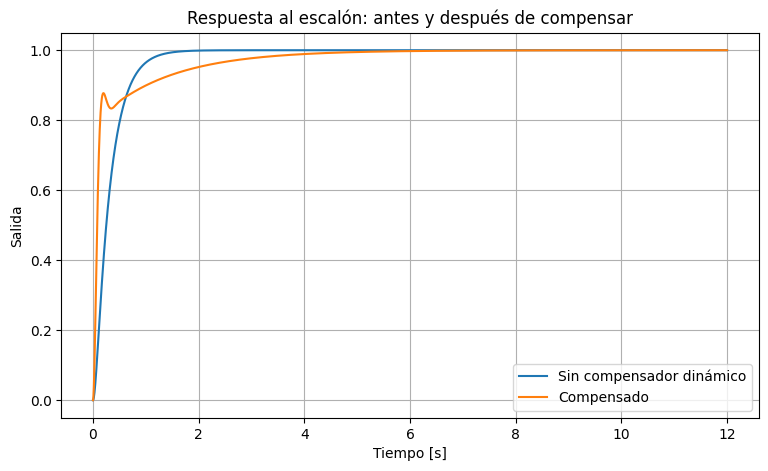

Indicadores sin compensar:
{'valor_final': np.float64(0.9999999999999958), 'valor_pico': np.float64(0.9999999999999959), 'sobrepico_%': np.float64(1.1102230246251613e-14), 'tiempo_subida_10_90': np.float64(0.6362120706902301), 'tiempo_establecimiento_2%': np.float64(1.160386795598533)}

Indicadores compensado:
{'valor_final': np.float64(0.9999712165501787), 'valor_pico': np.float64(0.9999712165501787), 'sobrepico_%': 0, 'tiempo_subida_10_90': np.float64(0.98432810936979), 'tiempo_establecimiento_2%': np.float64(3.1810603534511506)}


In [12]:
t = np.linspace(0, 12, 3000)

t1, y1 = signal.step(T_uncomp, T=t)
t2, y2 = signal.step(T_comp, T=t)

plt.figure()
plt.plot(t1, y1, label="Sin compensador dinámico")
plt.plot(t2, y2, label="Compensado")
plt.title("Respuesta al escalón: antes y después de compensar")
plt.xlabel("Tiempo [s]")
plt.ylabel("Salida")
plt.legend()
plt.show()

def step_info(t, y, tol=0.02):
    y = np.asarray(y)
    t = np.asarray(t)
    yf = y[-1]
    yp = np.max(y)

    Mp = np.nan
    if abs(yf) > 1e-12:
        Mp = max(0, (yp-yf)/abs(yf)*100)

    band = tol*max(abs(yf), 1e-12)
    outside = np.where(np.abs(y-yf) > band)[0]
    ts = t[outside[-1]+1] if len(outside) and outside[-1]+1 < len(t) else t[0]

    def first_cross(level):
        idx = np.where(y >= level)[0]
        return t[idx[0]] if len(idx) else np.nan

    tr = first_cross(0.9*yf) - first_cross(0.1*yf)

    return {
        "valor_final": yf,
        "valor_pico": yp,
        "sobrepico_%": Mp,
        "tiempo_subida_10_90": tr,
        "tiempo_establecimiento_2%": ts
    }

print("Indicadores sin compensar:")
print(step_info(t1, y1))

print("\nIndicadores compensado:")
print(step_info(t2, y2))

# 14. Análisis frecuencial: Bode

Se grafica el diagrama de Bode del lazo abierto:

- antes de compensar;
- después de compensar.

Esto permite observar el efecto del compensador sobre magnitud y fase.

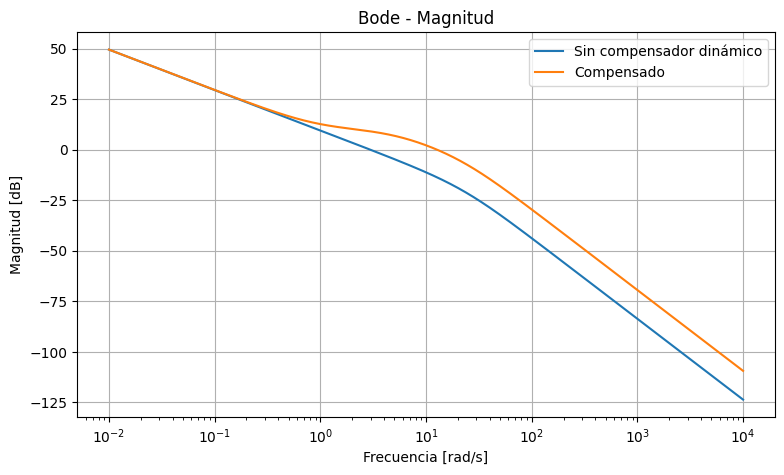

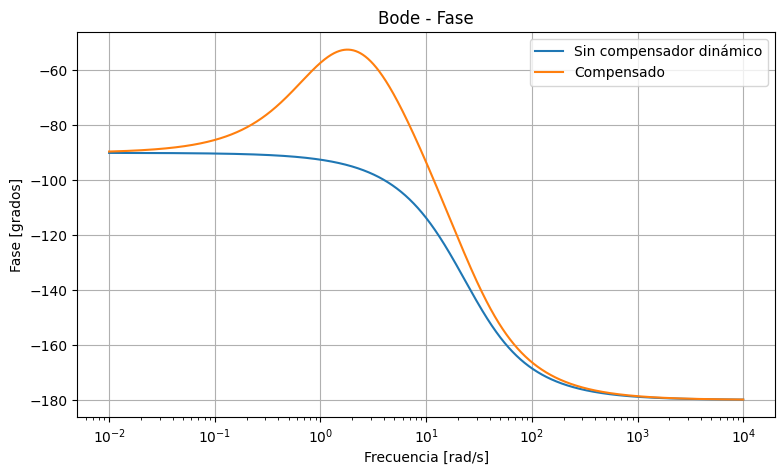

In [13]:
def bode_from_tf(num, den, label):
    sys = signal.TransferFunction(num, den)
    w = np.logspace(-2, 4, 3000)
    w, mag, phase = signal.bode(sys, w=w)
    return w, mag, phase, label

w0, mag0, phase0, label0 = bode_from_tf(num_ol_uncomp, den_ol_uncomp, "Sin compensador dinámico")
w1, mag1, phase1, label1 = bode_from_tf(num_ol_comp, den_ol_comp, "Compensado")

plt.figure()
plt.semilogx(w0, mag0, label=label0)
plt.semilogx(w1, mag1, label=label1)
plt.title("Bode - Magnitud")
plt.xlabel("Frecuencia [rad/s]")
plt.ylabel("Magnitud [dB]")
plt.legend()
plt.show()

plt.figure()
plt.semilogx(w0, phase0, label=label0)
plt.semilogx(w1, phase1, label=label1)
plt.title("Bode - Fase")
plt.xlabel("Frecuencia [rad/s]")
plt.ylabel("Fase [grados]")
plt.legend()
plt.show()

# 15. Análisis de Nyquist

El diagrama de Nyquist permite analizar la relación del lazo abierto con el punto crítico:

$$
-1+j0
$$

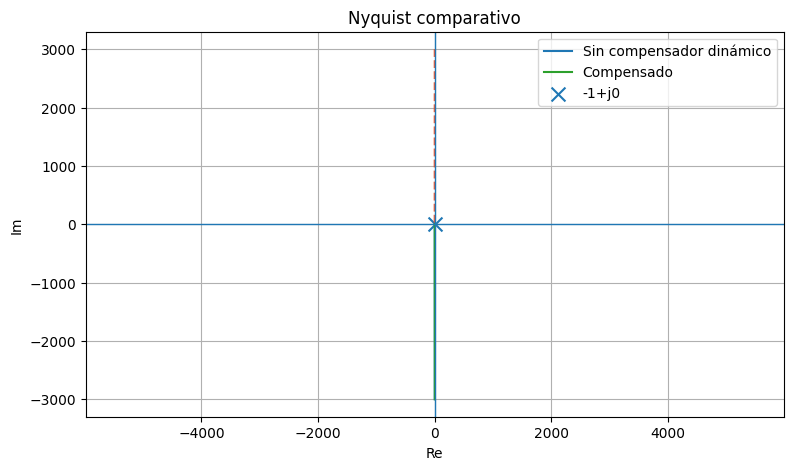

In [14]:
def nyquist_plot(num, den, label):
    w = np.logspace(-3, 4, 5000)
    s = 1j*w
    H = np.polyval(num, s)/np.polyval(den, s)
    plt.plot(np.real(H), np.imag(H), label=label)
    plt.plot(np.real(H), -np.imag(H), linestyle="--", alpha=0.6)

plt.figure()
nyquist_plot(num_ol_uncomp, den_ol_uncomp, "Sin compensador dinámico")
nyquist_plot(num_ol_comp, den_ol_comp, "Compensado")
plt.scatter([-1], [0], marker="x", s=100, label="-1+j0")
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.title("Nyquist comparativo")
plt.xlabel("Re")
plt.ylabel("Im")
plt.legend()
plt.axis("equal")
plt.show()

# 16. Lugar geométrico de las raíces

Se grafica el lugar geométrico de las raíces del sistema compensado.

El compensador modifica la geometría del lugar de raíces mediante la incorporación de un polo y un cero.

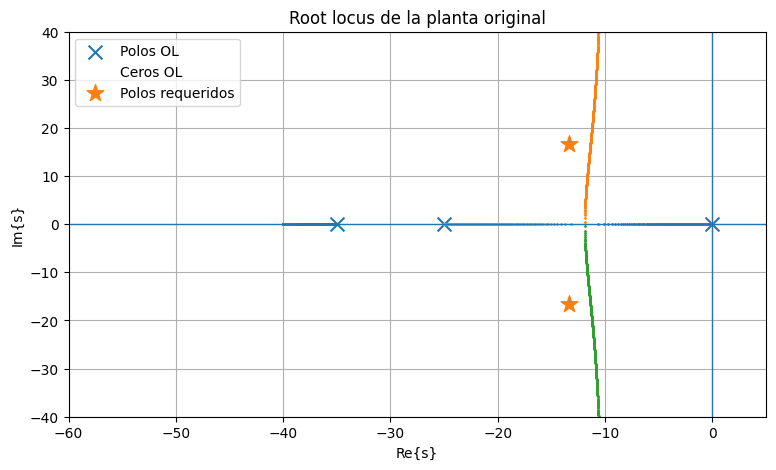

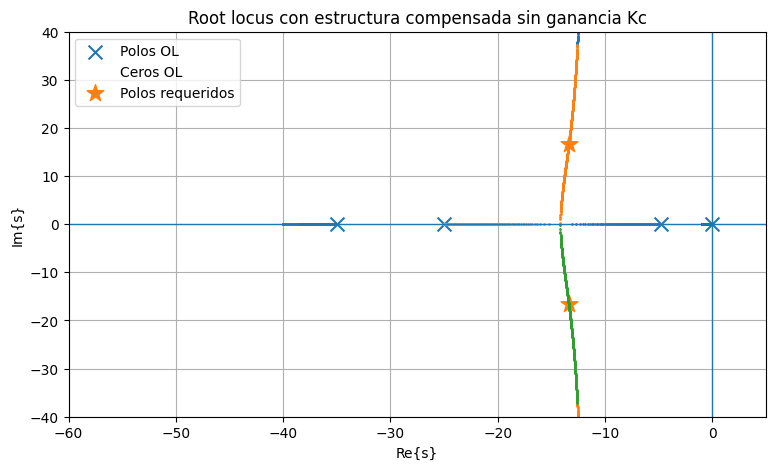

In [15]:
def root_locus(num, den, k_values=None, title="Root locus"):
    if k_values is None:
        k_values = np.logspace(-3, 5, 1600)

    roots = []
    for K in k_values:
        roots.append(np.roots(np.polyadd(den, K*num)))

    roots = np.array(roots)

    plt.figure()
    for i in range(roots.shape[1]):
        plt.plot(np.real(roots[:, i]), np.imag(roots[:, i]), ".", markersize=2)

    poles = np.roots(den)
    zeros = np.roots(num)

    plt.scatter(np.real(poles), np.imag(poles), marker="x", s=100, label="Polos OL")
    plt.scatter(np.real(zeros), np.imag(zeros), marker="o", facecolors="none", s=100, label="Ceros OL")

    plt.scatter([np.real(sd1), np.real(sd2)], [np.imag(sd1), np.imag(sd2)], marker="*", s=160, label="Polos requeridos")

    plt.axhline(0, linewidth=1)
    plt.axvline(0, linewidth=1)
    plt.title(title)
    plt.xlabel("Re{s}")
    plt.ylabel("Im{s}")
    plt.legend()
    plt.xlim(-60, 5)
    plt.ylim(-40, 40)
    plt.show()

root_locus(num_p, den_p, title="Root locus de la planta original")
root_locus(num_ol_comp/Kc, den_ol_comp, title="Root locus con estructura compensada sin ganancia Kc")

# 17. Discusión técnica

El diseño obtenido satisface algebraicamente:

- el par complejo asociado a $\zeta=0.628$;
- la frecuencia natural $\omega_n=21.324$ rad/s;
- la constante de error de velocidad $K_v=3$.

Sin embargo, es importante observar que el sistema compensado es de cuarto orden.  
Por lo tanto, además del par complejo requerido, aparecen polos reales adicionales.

En particular, uno de esos polos puede quedar más cerca del origen que el par complejo.  
Esto significa que, aunque el par solicitado esté presente, la respuesta temporal completa puede verse influida por ese polo real.

Esta observación es importante desde el punto de vista de ingeniería:

- cumplir una ubicación parcial de polos no siempre garantiza dominancia;
- el análisis debe incluir todos los polos;
- la simulación al escalón es indispensable para validar el comportamiento real;
- si se exigiera dominancia estricta del par complejo, podría requerirse un compensador de orden superior o una estrategia de diseño adicional.

El informe conserva esta advertencia porque forma parte del análisis responsable del sistema.

# 18. Conclusiones

Se diseñó un compensador estándar de primer orden:

$$
G_c(s)=K_c\frac{s+a}{s+b}
$$

para la planta:

$$
G_p(s)=\frac{s+40}{s(s+25)(s+35)}
$$

El diseño permite que el sistema compensado cumpla:

$$
\zeta=0.628
$$

$$
\omega_n=21.324 \; rad/s
$$

$$
K_v=3
$$

La respuesta al escalón fue simulada antes y después de la compensación.  
También se incluyeron análisis de polos, Bode, Nyquist y lugar geométrico de las raíces.

Desde el punto de vista académico, el trabajo muestra el procedimiento completo de diseño, verificación y simulación.

# 19. Código final resumido

La siguiente celda resume los parámetros principales del diseño.

In [16]:
print("RESUMEN FINAL")
print("=============")

print("\nPlanta:")
print("Gp(s) = (s + 40) / (s^3 + 60s^2 + 875s)")

print("\nRequerimientos:")
print("zeta =", zeta)
print("wn   =", wn)
print("Kv   =", Kv_req)

print("\nCompensador diseñado:")
print(f"Gc(s) = {Kc:.6f} (s + {a:.6f}) / (s + {b:.6f})")

print("\nPolos de lazo cerrado compensado:")
for p in poles_comp:
    print(p)

print("\nVerificación del par complejo:")
print("zeta obtenido =", zeta_obt)
print("wn obtenido   =", wn_obt)
print("wd obtenido   =", wd_obt)

print("\nKv compensado =", Kv_comp)

RESUMEN FINAL

Planta:
Gp(s) = (s + 40) / (s^3 + 60s^2 + 875s)

Requerimientos:
zeta = 0.628
wn   = 21.324
Kv   = 3

Compensador diseñado:
Gc(s) = 337.944409 (s + 0.929892) / (s + 4.788596)

Polos de lazo cerrado compensado:
(-37.263807728764576+0j)
(-13.39147200000004+16.594621227169267j)
(-13.39147200000004-16.594621227169267j)
(-0.7418446367445001+0j)

Verificación del par complejo:
zeta obtenido = 0.6280000000000006
wn obtenido   = 21.324000000000044
wd obtenido   = 16.594621227169267

Kv compensado = 2.9999999999993463


# 20. Análisis complementario: respuesta a rampa, parábola y otras entradas

La respuesta al escalón no siempre revela el objetivo central de un diseño de control.

En este trabajo, uno de los requerimientos principales fue:

$$
K_v = 3
$$

La constante $K_v$ no está asociada al error ante una entrada escalón, sino al error ante una entrada rampa.

Por eso, aunque la respuesta al escalón del sistema compensado pueda parecer menos favorable que la original, el análisis debe completarse evaluando entradas de mayor orden.

## 20.1 Constantes de error estacionario

Para sistemas con realimentación unitaria:

$$
E(s)=\frac{R(s)}{1+G_{OL}(s)}
$$

Las constantes clásicas de error son:

$$
K_p=\lim_{s\to 0}G_{OL}(s)
$$

$$
K_v=\lim_{s\to 0}sG_{OL}(s)
$$

$$
K_a=\lim_{s\to 0}s^2G_{OL}(s)
$$

Estas constantes se asocian a:

| Entrada | Forma temporal | Transformada | Constante |
|---|---:|---:|---:|
| Escalón | $r(t)=1$ | $R(s)=1/s$ | $K_p$ |
| Rampa | $r(t)=t$ | $R(s)=1/s^2$ | $K_v$ |
| Parábola | $r(t)=t^2/2$ | $R(s)=1/s^3$ | $K_a$ |

In [17]:
def eval_poly(num, s):
    return np.polyval(num, s)

def G_eval(num, den, s):
    return eval_poly(num, s) / eval_poly(den, s)

def error_constants(num_ol, den_ol):
    """
    Calcula aproximaciones numéricas de Kp, Kv y Ka
    evaluando cerca de s = 0.
    """
    eps = 1e-8
    G0 = G_eval(num_ol, den_ol, eps)
    Kp = G0
    Kv = eps * G0
    Ka = eps**2 * G0
    return Kp, Kv, Ka

Kp_u, Kv_u, Ka_u = error_constants(num_ol_uncomp, den_ol_uncomp)
Kp_c, Kv_c, Ka_c = error_constants(num_ol_comp, den_ol_comp)

print("Constantes aproximadas - sistema sin compensador dinámico")
print("Kp =", Kp_u)
print("Kv =", Kv_u)
print("Ka =", Ka_u)

print("\nConstantes aproximadas - sistema compensado")
print("Kp =", Kp_c)
print("Kv =", Kv_c)
print("Ka =", Ka_c)

Constantes aproximadas - sistema sin compensador dinámico
Kp = 299999999.8692857
Kv = 2.999999998692857
Ka = 2.999999998692857e-08

Constantes aproximadas - sistema compensado
Kp = 300000002.46891475
Kv = 3.0000000246891476
Ka = 3.000000024689148e-08


## 20.2 Error estacionario esperado

Para realimentación unitaria:

### Entrada escalón

$$
e_{ss}=\frac{1}{1+K_p}
$$

### Entrada rampa

$$
e_{ss}=\frac{1}{K_v}
$$

### Entrada parabólica

$$
e_{ss}=\frac{1}{K_a}
$$

En un sistema tipo 1:

- ante escalón: error estacionario nulo;
- ante rampa: error estacionario finito;
- ante parábola: error estacionario infinito.

Como la planta posee un integrador, el sistema es de tipo 1. Por eso tiene sentido que el requerimiento sea $K_v=3$.

In [18]:
def expected_steady_errors(Kp, Kv, Ka):
    e_step = 0 if np.isinf(Kp) or abs(Kp) > 1e8 else 1/(1+Kp)
    e_ramp = np.inf if abs(Kv) < 1e-12 else 1/Kv
    e_parabola = np.inf if abs(Ka) < 1e-12 else 1/Ka
    return e_step, e_ramp, e_parabola

e_step_u, e_ramp_u, e_parab_u = expected_steady_errors(Kp_u, Kv_u, Ka_u)
e_step_c, e_ramp_c, e_parab_c = expected_steady_errors(Kp_c, Kv_c, Ka_c)

print("Errores esperados - sin compensador dinámico")
print("Escalón :", e_step_u)
print("Rampa   :", e_ramp_u)
print("Parábola:", e_parab_u)

print("\nErrores esperados - compensado")
print("Escalón :", e_step_c)
print("Rampa   :", e_ramp_c)
print("Parábola:", e_parab_c)

Errores esperados - sin compensador dinámico
Escalón : 0
Rampa   : 0.3333333334785714
Parábola: 33333333.347857144

Errores esperados - compensado
Escalón : 0
Rampa   : 0.33333333059009473
Parábola: 33333333.05900947


## 20.3 Simulación de seguimiento de referencia

Para analizar entradas distintas al escalón, se simula el sistema de lazo cerrado ante:

- escalón;
- rampa;
- parábola;
- senoidal.

El sistema de lazo cerrado recibe como entrada la referencia $r(t)$ y entrega la salida $y(t)$.

El error se calcula como:

$$
e(t)=r(t)-y(t)
$$

In [19]:
def simulate_response(sys, t, u):
    """
    Simula respuesta de un sistema LTI continuo ante una entrada arbitraria u(t).
    """
    tout, y, x = signal.lsim(sys, U=u, T=t)
    return tout, y

def plot_tracking(sys1, sys2, t, r, title, label1="Sin compensador dinámico", label2="Compensado"):
    t1, y1 = simulate_response(sys1, t, r)
    t2, y2 = simulate_response(sys2, t, r)

    e1 = r - y1
    e2 = r - y2

    plt.figure()
    plt.plot(t, r, "k--", label="Referencia")
    plt.plot(t1, y1, label=label1)
    plt.plot(t2, y2, label=label2)
    plt.title(title)
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Salida")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(t, e1, label=f"Error - {label1}")
    plt.plot(t, e2, label=f"Error - {label2}")
    plt.title("Error de seguimiento: " + title)
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Error")
    plt.legend()
    plt.show()

    print("Error final aproximado:")
    print(label1, ":", e1[-1])
    print(label2, ":", e2[-1])

    return y1, y2, e1, e2

## 20.4 Respuesta ante entrada rampa

La entrada rampa es:

$$
r(t)=t
$$

Su transformada es:

$$
R(s)=\frac{1}{s^2}
$$

Para un sistema tipo 1, el error estacionario ante rampa es finito:

$$
e_{ss}=\frac{1}{K_v}
$$

Como se diseñó el sistema para:

$$
K_v=3
$$

se espera:

$$
e_{ss}=\frac{1}{3}=0.3333
$$

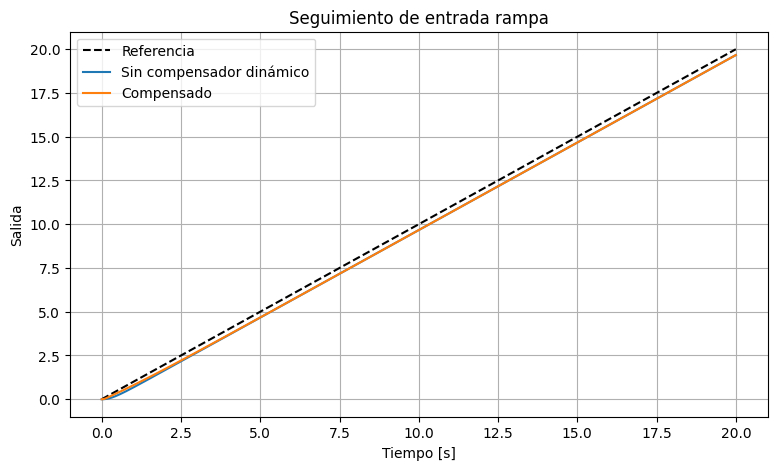

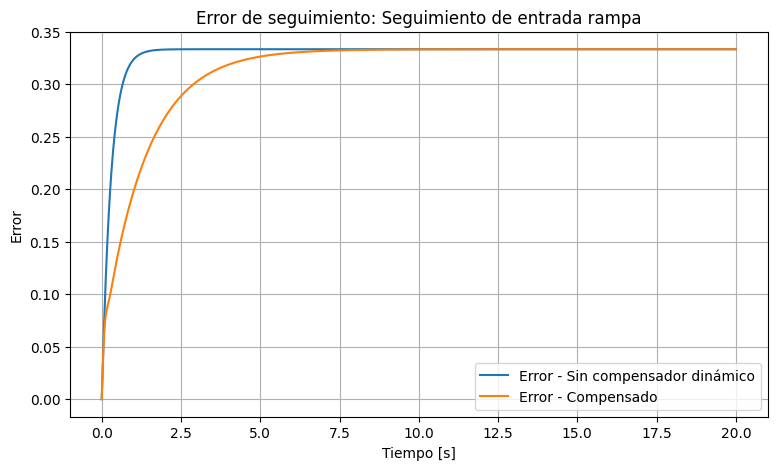

Error final aproximado:
Sin compensador dinámico : 0.3333333333333286
Compensado : 0.3333332306742207

Valor teórico esperado para rampa si Kv = 3:
e_ss = 1/Kv = 0.3333333333333333


In [20]:
t_ramp = np.linspace(0, 20, 4000)
r_ramp = t_ramp

y1_ramp, y2_ramp, e1_ramp, e2_ramp = plot_tracking(
    T_uncomp,
    T_comp,
    t_ramp,
    r_ramp,
    "Seguimiento de entrada rampa"
)

print("\nValor teórico esperado para rampa si Kv = 3:")
print("e_ss = 1/Kv =", 1/Kv_req)

## 20.5 Respuesta ante entrada parabólica

La entrada parabólica normalizada es:

$$
r(t)=\frac{t^2}{2}
$$

Su transformada es:

$$
R(s)=\frac{1}{s^3}
$$

Para que el error estacionario ante parábola sea finito, el sistema debe ser de tipo 2.

Como la planta compensada sigue siendo de tipo 1, se espera que el error ante entrada parabólica crezca sin cota.

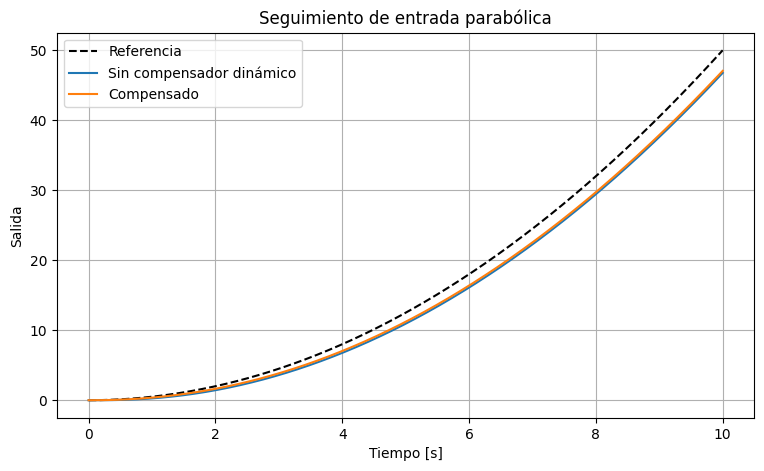

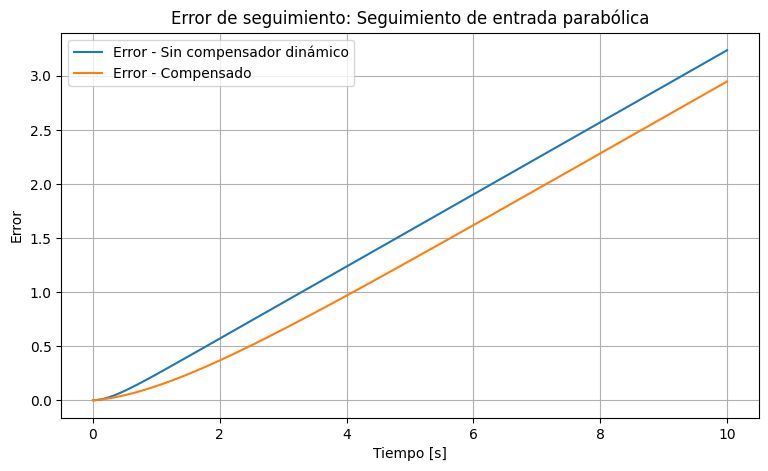

Error final aproximado:
Sin compensador dinámico : 3.2367451051914244
Compensado : 2.948120777663675


In [21]:
t_par = np.linspace(0, 10, 3000)
r_par = 0.5 * t_par**2

y1_par, y2_par, e1_par, e2_par = plot_tracking(
    T_uncomp,
    T_comp,
    t_par,
    r_par,
    "Seguimiento de entrada parabólica"
)

## 20.6 Respuesta ante entrada senoidal

También resulta útil analizar una referencia senoidal:

$$
r(t)=\sin(\omega t)
$$

Esta entrada permite observar el comportamiento dinámico frente a una frecuencia específica.

Se utiliza una frecuencia baja para evaluar seguimiento y desfase.

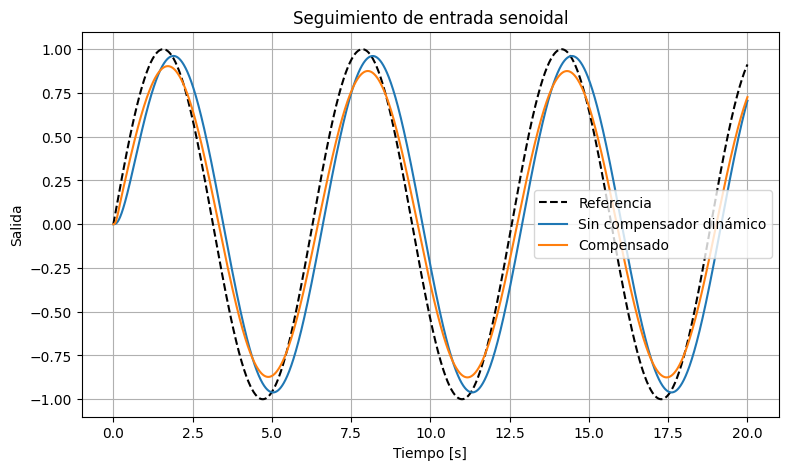

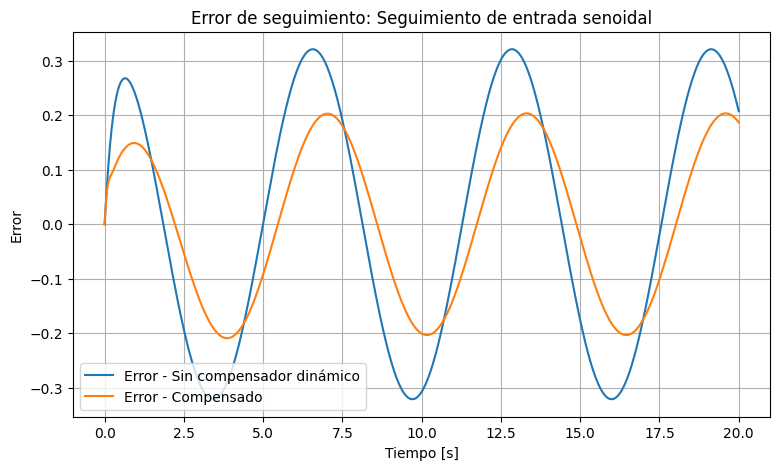

Error final aproximado:
Sin compensador dinámico : 0.20732685189529843
Compensado : 0.18659446880251018


In [22]:
t_sin = np.linspace(0, 20, 4000)
omega_ref = 1.0
r_sin = np.sin(omega_ref * t_sin)

y1_sin, y2_sin, e1_sin, e2_sin = plot_tracking(
    T_uncomp,
    T_comp,
    t_sin,
    r_sin,
    "Seguimiento de entrada senoidal"
)

## 20.7 Respuesta ante entrada escalón de velocidad limitada

Un escalón ideal exige un cambio instantáneo, lo cual puede ser poco físico.  
En sistemas reales, muchas referencias son suaves o limitadas por pendiente.

Se propone una referencia tipo rampa saturada:

$$
r(t)=
\begin{cases}
t/T_r, & 0 \leq t < T_r \\
1, & t \geq T_r
\end{cases}
$$

Esto permite observar una referencia más realista que un escalón ideal.

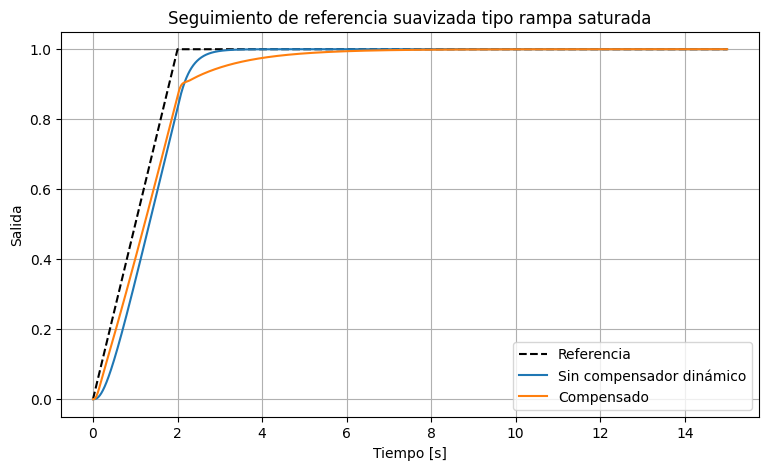

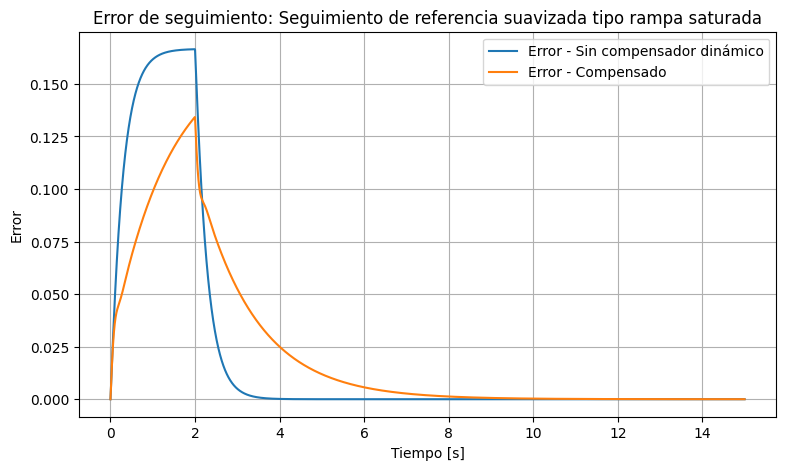

Error final aproximado:
Sin compensador dinámico : 2.886579864025407e-15
Compensado : 7.143539899279183e-06


In [23]:
t_soft = np.linspace(0, 15, 3000)
Tr = 2.0
r_soft = np.minimum(t_soft/Tr, 1.0)

y1_soft, y2_soft, e1_soft, e2_soft = plot_tracking(
    T_uncomp,
    T_comp,
    t_soft,
    r_soft,
    "Seguimiento de referencia suavizada tipo rampa saturada"
)

## 20.8 Comparación de errores finales

Se comparan los errores finales aproximados para las distintas entradas.

Esta comparación permite ver que el diseño no debe evaluarse solamente con la respuesta al escalón.

In [24]:
summary_errors = {
    "Rampa": {
        "Sin compensador dinámico": e1_ramp[-1],
        "Compensado": e2_ramp[-1],
    },
    "Parábola": {
        "Sin compensador dinámico": e1_par[-1],
        "Compensado": e2_par[-1],
    },
    "Senoidal": {
        "Sin compensador dinámico": e1_sin[-1],
        "Compensado": e2_sin[-1],
    },
    "Rampa saturada": {
        "Sin compensador dinámico": e1_soft[-1],
        "Compensado": e2_soft[-1],
    },
}

for entrada, datos in summary_errors.items():
    print("\nEntrada:", entrada)
    for sistema, err in datos.items():
        print(f"{sistema}: error final aproximado = {err}")


Entrada: Rampa
Sin compensador dinámico: error final aproximado = 0.3333333333333286
Compensado: error final aproximado = 0.3333332306742207

Entrada: Parábola
Sin compensador dinámico: error final aproximado = 3.2367451051914244
Compensado: error final aproximado = 2.948120777663675

Entrada: Senoidal
Sin compensador dinámico: error final aproximado = 0.20732685189529843
Compensado: error final aproximado = 0.18659446880251018

Entrada: Rampa saturada
Sin compensador dinámico: error final aproximado = 2.886579864025407e-15
Compensado: error final aproximado = 7.143539899279183e-06


# 21. Interpretación conceptual del análisis complementario

El análisis muestra que la respuesta al escalón no es suficiente para juzgar el sentido del compensador.

El requerimiento de diseño incluye:

$$
K_v=3
$$

Esto orienta el diseño hacia el seguimiento de referencias tipo rampa, no exclusivamente hacia la mejora visual del escalón.

Por lo tanto, el ejercicio tiene sentido porque obliga a distinguir:

- respuesta transitoria;
- error estacionario;
- tipo del sistema;
- entrada de prueba;
- polos dominantes;
- polos no dominantes;
- cumplimiento algebraico;
- desempeño físico real.

Una conclusión importante es que un sistema compensado puede no presentar una respuesta al escalón aparentemente superior y, aun así, cumplir mejor un criterio específico de seguimiento.

También se observa que el par complejo diseñado cumple los valores requeridos de $\zeta$ y $\omega_n$, pero el sistema completo posee polos adicionales. Por ello, debe analizarse la dominancia real de todos los polos, no solo del par complejo impuesto.

# 22. Conclusión ampliada

El compensador diseñado cumple los requerimientos especificados:

$$
\zeta=0.628
$$

$$
\omega_n=21.324 \; rad/s
$$

$$
K_v=3
$$

Sin embargo, la comparación con la planta sin compensador dinámico evidencia que el escalón no es la única entrada relevante para evaluar el desempeño.

El análisis de rampa confirma el rol de $K_v$ como constante asociada al error estacionario de velocidad.

El análisis de parábola muestra la limitación estructural del sistema tipo 1: el error no queda acotado para entradas de aceleración constante.

El análisis senoidal permite observar diferencias de seguimiento y fase ante referencias periódicas.

Por lo tanto, el trabajo práctico no debe interpretarse como una simple mejora de la curva de escalón, sino como un ejercicio de diseño sujeto a especificaciones simultáneas y con compromisos dinámicos reales.